In [70]:
#Importing necessary Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pylab import savefig

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import cut_tree

import warnings
warnings.filterwarnings('ignore') # if there are any warning due to version mismatch, it will be ignored


In [71]:
#Sample file name :kdd_train_raw_VAE, kdd_traidd_train_raw_AE_16.csvn_raw_AE_16

inp_file_train=input("Enter the file name:")


Enter the file name:kdd_train_prep2_AE_16.csv


In [72]:
#Sample file name :kdd_test_raw_VAE, kdd_test_raw_AE_16

inp_file_test=input("Enter the file name:")


Enter the file name:kdd_test_prep2_AE_16.csv


In [73]:
kdd_train= pd.read_csv(inp_file_train)
kdd_test= pd.read_csv(inp_file_test)

In [74]:
kdd_train.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,attack,label_2,label_5
0,-0.610296,0.015692,0.244279,0.352686,0.098302,0.051205,0.565617,-0.170328,-0.480297,0.511893,-0.345205,-0.250245,0.153788,0.130683,-0.366020,-0.346798,normal,normal,Normal
1,-0.320414,0.225041,0.196417,-0.384774,0.432062,0.406118,0.382800,0.559388,-0.519861,-0.177007,-0.744207,-0.138819,-0.454534,0.392854,0.114113,0.263254,normal,normal,Normal
2,-0.210321,-0.071026,-0.171084,-0.365576,-0.110038,-0.556859,-0.402690,0.084724,-0.611879,0.180990,0.096818,-0.182272,0.125824,-0.161088,0.018052,-0.070688,neptune,attack,DoS
3,-0.441472,0.564467,0.409877,0.100399,0.048755,-0.295239,0.259262,0.316888,0.427560,0.090938,0.158638,0.115800,0.299641,0.295628,-0.219366,-0.127190,normal,normal,Normal
4,-0.478021,0.467678,0.487974,0.169323,0.023412,-0.274956,0.272012,0.305003,0.447077,-0.031349,0.182353,0.156466,0.240548,0.295724,-0.003925,-0.067835,normal,normal,Normal


In [75]:
label_list=['attack', 'label_2','label_5']
kdd_label=kdd_train[label_list]
kdd_test_label=kdd_test[label_list]

In [76]:
from sklearn.preprocessing import LabelEncoder

LE = LabelEncoder()
kdd_label['Class_2'] = LE.fit_transform(kdd_train['label_2'])
kdd_label['Class_5'] = LE.fit_transform(kdd_train['label_5'])
kdd_test_label['Class_2'] = LE.fit_transform(kdd_test['label_2'])
kdd_test_label['Class_5'] = LE.fit_transform(kdd_test['label_5'])



In [77]:
kdd_train['label_5'].value_counts()

Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: label_5, dtype: int64

In [78]:
kdd_label['Class_2'].value_counts()

1    67343
0    58630
Name: Class_2, dtype: int64

In [79]:
kdd_label['Class_5'].value_counts()

1    67343
0    45927
2    11656
3      995
4       52
Name: Class_5, dtype: int64

In [80]:
kdd_train.drop(label_list, axis = 1, inplace = True)
kdd_test.drop(label_list, axis = 1, inplace = True)

In [81]:
kdd_train.shape

(125973, 16)

In [82]:
kdd_label.head()

,attack,label_2,label_5,Class_2,Class_5
0,normal,normal,Normal,1,1
1,normal,normal,Normal,1,1
2,neptune,attack,DoS,0,0
3,normal,normal,Normal,1,1
4,normal,normal,Normal,1,1


In [83]:
kdd_train.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15
0,-0.610296,0.015692,0.244279,0.352686,0.098302,0.051205,0.565617,-0.170328,-0.480297,0.511893,-0.345205,-0.250245,0.153788,0.130683,-0.366020,-0.346798
1,-0.320414,0.225041,0.196417,-0.384774,0.432062,0.406118,0.382800,0.559388,-0.519861,-0.177007,-0.744207,-0.138819,-0.454534,0.392854,0.114113,0.263254
2,-0.210321,-0.071026,-0.171084,-0.365576,-0.110038,-0.556859,-0.402690,0.084724,-0.611879,0.180990,0.096818,-0.182272,0.125824,-0.161088,0.018052,-0.070688
3,-0.441472,0.564467,0.409877,0.100399,0.048755,-0.295239,0.259262,0.316888,0.427560,0.090938,0.158638,0.115800,0.299641,0.295628,-0.219366,-0.127190
4,-0.478021,0.467678,0.487974,0.169323,0.023412,-0.274956,0.272012,0.305003,0.447077,-0.031349,0.182353,0.156466,0.240548,0.295724,-0.003925,-0.067835


## K means Clustering

In [112]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score

In [113]:
import time

start_time = time.time()

kmeans_2 = KMeans(algorithm='elkan', copy_x=True, init='random', max_iter=100,
    n_clusters=2, n_init=20, n_jobs=-1, precompute_distances=True,
    random_state=42, tol=0.0001, verbose=0)
kmeans_2.fit(kdd_train)

print("\n\nRun Time ->","--- %s seconds ---" % (time.time() - start_time))

kmeans_2.labels_
pred2=kmeans_2.labels_



Run Time -> --- 1.4150161743164062 seconds ---


In [114]:
import time

start_time = time.time()

kmeans_5 = KMeans(algorithm='elkan', copy_x=True, init='random', max_iter=100,
    n_clusters=5, n_init=20, n_jobs=-1, precompute_distances=True,
    random_state=42, tol=0.0001, verbose=0)
kmeans_5.fit(kdd_train)

print("\n\nRun Time ->","--- %s seconds ---" % (time.time() - start_time))

pred5=kmeans_5.labels_



Run Time -> --- 2.327392578125 seconds ---


In [115]:
kdd_label['pred_2']=pred2
kdd_label['pred_5']=pred5

kdd_label.head()

,attack,label_2,label_5,Class_2,Class_5,pred_2,pred_5
0,normal,normal,Normal,1,1,1,4
1,normal,normal,Normal,1,1,1,1
2,neptune,attack,DoS,0,0,0,3
3,normal,normal,Normal,1,1,1,4
4,normal,normal,Normal,1,1,1,4


In [116]:
kdd_label['pred_2'].value_counts()

0    64227
1    61746
Name: pred_2, dtype: int64

In [117]:
kdd_label['pred_5'].value_counts()

3    48037
4    46463
1    14976
2     8293
0     8204
Name: pred_5, dtype: int64

In [118]:
import numpy as np


def plot_confusion_matrix(cm,
                          target_names,
                          title='Confusion matrix',
                          cmap=None,
                          normalize=False):
    """
    given a sklearn confusion matrix (cm), make a nice plot

    Arguments
    ---------
    cm:           confusion matrix from sklearn.metrics.confusion_matrix

    target_names: given classification classes such as [0, 1, 2]
                  the class names, for example: ['high', 'medium', 'low']

    title:        the text to display at the top of the matrix

    cmap:         the gradient of the values displayed from matplotlib.pyplot.cm
                  see http://matplotlib.org/examples/color/colormaps_reference.html
                  plt.get_cmap('jet') or plt.cm.Blues

    normalize:    If False, plot the raw numbers
                  If True, plot the proportions

    Usage
    -----
    plot_confusion_matrix(cm           = cm,                  # confusion matrix created by
                                                              # sklearn.metrics.confusion_matrix
                          normalize    = True,                # show proportions
                          target_names = y_labels_vals,       # list of names of the classes
                          title        = best_estimator_name) # title of graph

    Citiation
    ---------
    http://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html

    """
    import matplotlib.pyplot as plt
    import numpy as np
    import itertools

    accuracy = np.trace(cm) / float(np.sum(cm))
    misclass = 1 - accuracy

    if cmap is None:
        cmap = plt.get_cmap('Blues')

    plt.figure(figsize=(5, 5))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()

    if target_names is not None:
        tick_marks = np.arange(len(target_names))
        plt.xticks(tick_marks, target_names, rotation=45)
        plt.yticks(tick_marks, target_names)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


    thresh = cm.max() / 1.5 if normalize else cm.max() / 1.5
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        if normalize:
            plt.text(j, i, "{:0.4f}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="blue" if cm[i, j] > thresh else "black")
        else:
            plt.text(j, i, "{:,}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")


    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label\naccuracy={:0.4f}; misclass={:0.4f}'.format(accuracy, misclass))
    plt.show()


In [119]:
def metrics_df_2(y_train, y_pred):
    
    
    print("\n*********************************SKLEARN METRICS***********\n")
    import sklearn.metrics
    print(sklearn.metrics.classification_report(y_train,  y_pred),"\n\n")
    print("Confusion Matrix :\n",sklearn.metrics.confusion_matrix(y_train, y_pred))

    print("Accuracy : \t",sklearn.metrics.accuracy_score(y_train, y_pred,normalize=True))

    print("F1_score : \t",sklearn.metrics.f1_score(y_train, y_pred))

    print("Precision : \t",sklearn.metrics.precision_score(y_train, y_pred))

    print("Recall : \t",sklearn.metrics.recall_score(y_train, y_pred))

    print("ROC_AUC : \t",sklearn.metrics.roc_auc_score(y_train, y_pred))  
    print("\n*************************CLUSTER PAARMETERS***********\n")
    
    print("Normalized MI : \t",sklearn.metrics.normalized_mutual_info_score(y_train, y_pred)) 
    print("Adj_Rand_score : \t",sklearn.metrics.adjusted_rand_score(y_train, y_pred))
    print("HomogenityScore : \t",sklearn.metrics.homogeneity_score(y_train, y_pred))   
    
    print("\n*************************CONFUSION MATRIX***********\n")
    from sklearn.metrics import confusion_matrix
    confusion=sklearn.metrics.confusion_matrix(y_train, y_pred)
    TP = confusion[1,1] # true positive 
    TN = confusion[0,0] # true negatives
    FP = confusion[0,1] # false positives
    FN = confusion[1,0] # false negatives
    print(confusion)
    
        # Let's see the sensitivity of our logistic regression model
    print('Sensitivity :\t {}'.format(TP / float(TP+FN)))
    # Let us calculate specificity
    print('Specificity :\t {}'.format(TN / float(TN+FP)))
    # Let us calculate specificity
    print('Precision :\t {}'.format(TP / float(TP+FP)))
    # Calculate false postive rate - predicting churn when customer does not have churned
    print('Accuracy :\t {}'.format((TP + TN)/ float(TP + TN + FP + FN)))

    print('Detection Rate  :\t {}'.format(TP/ float(TP + TN + FP + FN)))

    print('False Positive Rate :\t {}'.format(FP/ float(TN+FP)))
    #False Negative
    print('False Negative Rate  :\t {}'.format(FN/ float(TP+FN)))
    ## Misclassification Rtae : FP + FN / TP + TN + FP + FN
    print('Missclassification Rate :\t {}'.format((FP + FN)/ float(TP + TN + FP + FN)))
    # positive predictive value 
    print('Positive predictive value :\t {}'.format(TP / float(TP+FP)))
    # Negative predictive value
    print('Negative Predictive value :\t {}'.format(TN / float(TN+ FN)))
    
    plot_confusion_matrix(confusion,['attack','normal'])


In [120]:
def metrics_df_5(y_train, y_pred):
    
    print("\n*********************************SKLEARN METRICS***********\n")
    import sklearn.metrics
    print(sklearn.metrics.classification_report(y_train,  y_pred),"\n\n")
    

    
    print("\n*************************CLUSTER***********\n")
    
    print("Normalized MI : \t",sklearn.metrics.normalized_mutual_info_score(y_train, y_pred)) 
    print("Adj_Rand_score : \t",sklearn.metrics.adjusted_rand_score(y_train, y_pred))
    print("HomogenityScore : \t",sklearn.metrics.homogeneity_score(y_train, y_pred))   
    
    print("\n************************* MULTI CONFUSION MATRIX***********\n")
    print("Confusion Matrix :\n",sklearn.metrics.confusion_matrix(y_train, y_pred))

    
    cm=sklearn.metrics.confusion_matrix(y_train, y_pred)
    target_names=['DoS','Normal','Probe',"R2L",'U2R']
    plot_confusion_matrix_multi(cm,
                          target_names,
                          title='Confusion matrix',
                          cmap=None,
                          normalize=False)
    

In [121]:
def metrics_attack(y_test, y_pred):
        #importing accuracy_score, precision_score, recall_score, f1_score
        import sklearn.metrics
        from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
        print('\nAccuracy: {:.5f}'.format(accuracy_score(y_test, y_pred)))
        
        print("Normalized MI : \t",sklearn.metrics.normalized_mutual_info_score(y_test, y_pred)) 
        print("Adj_Rand_score : \t",sklearn.metrics.adjusted_rand_score(y_test, y_pred))
        print("HomogenityScore : \t",sklearn.metrics.homogeneity_score(y_test, y_pred))   
    

        print('\nMicro Precision: {:.5f}'.format(precision_score(y_test, y_pred, average='micro')))
        print('Micro Recall: {:.5f}'.format(recall_score(y_test, y_pred, average='micro')))
        print('Micro F1-score: {:.5f}\n'.format(f1_score(y_test, y_pred, average='micro')))

        print('Macro Precision: {:.5f}'.format(precision_score(y_test, y_pred, average='macro')))
        print('Macro Recall: {:.5f}'.format(recall_score(y_test, y_pred, average='macro')))
        print('Macro F1-score: {:.5f}\n'.format(f1_score(y_test, y_pred, average='macro')))

        print('Weighted Precision: {:.5f}'.format(precision_score(y_test, y_pred, average='weighted')))
        print('Weighted Recall: {:.5f}'.format(recall_score(y_test, y_pred, average='weighted')))
        print('Weighted F1-score: {:.5f}'.format(f1_score(y_test, y_pred, average='weighted')))


In [122]:
import numpy as np


def plot_confusion_matrix_multi(cm,
                          target_names,
                          title='Confusion matrix',
                          cmap=None,
                          normalize=True):
    """
    given a sklearn confusion matrix (cm), make a nice plot

    Arguments
    ---------
    cm:           confusion matrix from sklearn.metrics.confusion_matrix

    target_names: given classification classes such as [0, 1, 2]
                  the class names, for example: ['high', 'medium', 'low']

    title:        the text to display at the top of the matrix

    cmap:         the gradient of the values displayed from matplotlib.pyplot.cm
                  see http://matplotlib.org/examples/color/colormaps_reference.html
                  plt.get_cmap('jet') or plt.cm.Blues

    normalize:    If False, plot the raw numbers
                  If True, plot the proportions

    Usage
    -----
    plot_confusion_matrix(cm           = cm,                  # confusion matrix created by
                                                              # sklearn.metrics.confusion_matrix
                          normalize    = True,                # show proportions
                          target_names = y_labels_vals,       # list of names of the classes
                          title        = best_estimator_name) # title of graph

    Citiation
    ---------
    http://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html

    """
    import matplotlib.pyplot as plt
    import numpy as np
    import itertools

    accuracy = np.trace(cm) / float(np.sum(cm))
    misclass = 1 - accuracy

    if cmap is None:
        cmap = plt.get_cmap('Blues')

    plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()

    if target_names is not None:
        tick_marks = np.arange(len(target_names))
        plt.xticks(tick_marks, target_names, rotation=45)
        plt.yticks(tick_marks, target_names)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


    thresh = cm.max() / 1.5 if normalize else cm.max() / 2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        if normalize:
            plt.text(j, i, "{:0.4f}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")
        else:
            plt.text(j, i, "{:,}".format(cm[i, j]),
                     horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")


    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label\naccuracy={:0.4f}; misclass={:0.4f}'.format(accuracy, misclass))
    plt.show()

In [123]:
def multilabel_confusion_matrix(y_true, y_pred, labels=None):
    """Compute True positive, False positive, True negative, False negative
    for a multilabel classification problem
    Parameters
    ----------
    y_true : array, shape = [n_samples]
        Ground truth (correct) target values.
    y_pred : array, shape = [n_samples]
        Estimated targets as returned by a classifier.
    labels : array, shape = [n_classes], optional
        List of labels to index the matrix. This may be used to reorder
        or select a subset of labels.
        If none is given, those that appear at least once
        in ``y_true`` or ``y_pred`` are used in sorted order.
    Returns
    -------
    C : array, shape = [n_classes, 4]
        where the columns are as follows
        0 : True positive for class i
        1 : False positives for class i
        2 : False negatives for class i
        3 : True negatives for class i
        Multi-label Confusion matrix
    References
    ----------
    .. [1] `Wikipedia entry for the Confusion matrix
           <http://en.wikipedia.org/wiki/Sensitivity_and_specificity>`_
       [2] http://www.cnts.ua.ac.be/~vincent/pdf/microaverage.pdf
    Examples
    --------
    >>> from sklearn.metrics import confusion_matrix
    >>> y_true = [2, 0, 2, 2, 0, 1]
    >>> y_pred = [0, 0, 2, 2, 0, 2]
    >>> multilabel_confusion_matrix(y_true, y_pred)
    array([[2, 1, 0, 3],
           [0, 0, 1, 5],
           [2, 1, 1, 2]])
    """
    #y_type, y_true, y_pred = _check_targets(y_true, y_pred)
    #if y_type not in ("binary", "multiclass"):
       # raise ValueError("%s is not supported" % y_type)
    from scipy.sparse import coo_matrix
    if labels is None:
        labels = unique_labels(y_true, y_pred)
    else:
        labels = np.asarray(labels)

    n_labels = labels.size
    labels_confusion_matrix = \
        np.transpose(confusion_matrix(y_true, y_pred, labels))
    # True positives are on the diagonal of the confusion matrix
    t_pos = np.diagonal(labels_confusion_matrix)
    # To get false negatives we count elements not on diagonal
    row_sum = np.sum(labels_confusion_matrix, axis=0)
    f_neg = np.subtract(row_sum, t_pos)
    # To calculate false positive we sum each row and
    # remove the diagonal from it
    column_sum = np.sum(labels_confusion_matrix, axis=1)
    f_pos = np.subtract(column_sum, t_pos)
    t_neg = np.subtract(np.repeat(np.sum(labels_confusion_matrix), n_labels),
                        np.subtract(np.add(column_sum, row_sum), t_pos))
    all_vals = np.hstack([t_pos, f_pos, f_neg, t_neg])
    rows = np.tile(range(0, n_labels), 4)
    columns = np.repeat(np.array([0, 1, 2, 3]), n_labels)
    mcm = coo_matrix((all_vals, (rows, columns)), shape=(n_labels, 4)).\
        toarray()
    return mcm


### 2-class metrics


In [124]:
kdd_label['pred_2']=pred2

In [125]:
print(pd.crosstab(kdd_label['label_2'], kdd_label['pred_2']),"\n")


pred_2       0      1
label_2              
attack   52668   5962
normal   11559  55784 



In [126]:
print(pd.crosstab(kdd_label['label_5'], kdd_label['pred_2']),"\n")


pred_2       0      1
label_5              
DoS      41011   4916
Normal   11559  55784
Probe    11273    383
R2L        380    615
U2R          4     48 



kdd_label['pred_2']=kdd_label['pred_2'].apply(lambda x:1 if x==0 else 0)
kdd_label['pred_2'].value_counts()

In [127]:
print(pd.crosstab(kdd_label['label_2'], kdd_label['pred_2']),"\n")


pred_2       0      1
label_2              
attack   52668   5962
normal   11559  55784 




*********************************SKLEARN METRICS***********

             precision    recall  f1-score   support

          0       0.82      0.90      0.86     58630
          1       0.90      0.83      0.86     67343

avg / total       0.86      0.86      0.86    125973
 


Confusion Matrix :
 [[52668  5962]
 [11559 55784]]
Accuracy : 	 0.8609146404388242
F1_score : 	 0.8642719364159611
Precision : 	 0.9034431380170376
Recall : 	 0.8283563250820427
ROC_AUC : 	 0.8633338848674753

*************************CLUSTER PAARMETERS***********

Normalized MI : 	 0.42615666245198686
Adj_Rand_score : 	 0.5210328394569952
HomogenityScore : 	 0.42683473106557746

*************************CONFUSION MATRIX***********

[[52668  5962]
 [11559 55784]]
Sensitivity :	 0.8283563250820427
Specificity :	 0.898311444652908
Precision :	 0.9034431380170376
Accuracy :	 0.8609146404388242
Detection Rate  :	 0.44282504981226134
False Positive Rate :	 0.10168855534709194
False Negative Rate  :	 0.17164367491795

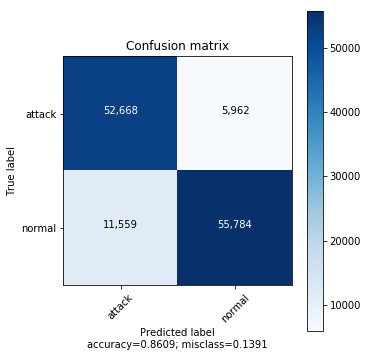

In [128]:
y_train=kdd_label['Class_2']
y_pred=kdd_label['pred_2']
metrics_df_2(y_train,y_pred)

### Five class metrics

In [138]:
kdd_label['pred_5']=pred5

In [139]:
print(pd.crosstab(kdd_label['Class_5'], kdd_label['pred_5']),"\n")


pred_5      0      1     2      3      4
Class_5                                 
0        1010    875  2847  39505   1690
1        7144  12434  1309   2385  44071
2          48   1664  4137   5789     18
3           2      0     0    351    642
4           0      3     0      7     42 



In [140]:
print(pd.crosstab(kdd_label['label_5'], kdd_label['pred_5']),"\n")


pred_5      0      1     2      3      4
label_5                                 
DoS      1010    875  2847  39505   1690
Normal   7144  12434  1309   2385  44071
Probe      48   1664  4137   5789     18
R2L         2      0     0    351    642
U2R         0      3     0      7     42 



In [141]:
kdd_label['pred_lb']=pred5
kdd_label['pred_lb'].replace(3,"DoS",inplace=True)
kdd_label['pred_lb'].replace(4,"Normal",inplace=True)
kdd_label['pred_lb'].replace(2,"Probe",inplace=True)
kdd_label['pred_lb'].replace(1,"R2L",inplace=True)
kdd_label['pred_lb'].replace(0,'U2R',inplace=True)

In [142]:
print(pd.crosstab(kdd_label['label_5'], kdd_label['pred_5']),"\n")


pred_5      0      1     2      3      4
label_5                                 
DoS      1010    875  2847  39505   1690
Normal   7144  12434  1309   2385  44071
Probe      48   1664  4137   5789     18
R2L         2      0     0    351    642
U2R         0      3     0      7     42 



In [143]:
print(pd.crosstab(kdd_label['label_5'], kdd_label['pred_lb']),"\n")


pred_lb    DoS  Normal  Probe    R2L   U2R
label_5                                   
DoS      39505    1690   2847    875  1010
Normal    2385   44071   1309  12434  7144
Probe     5789      18   4137   1664    48
R2L        351     642      0      0     2
U2R          7      42      0      3     0 



In [144]:
y_train=kdd_label['label_5']
y_pred=kdd_label['pred_lb']



*********************************SKLEARN METRICS***********

             precision    recall  f1-score   support

        DoS       0.82      0.86      0.84     45927
     Normal       0.95      0.65      0.77     67343
      Probe       0.50      0.35      0.41     11656
        R2L       0.00      0.00      0.00       995
        U2R       0.00      0.00      0.00        52

avg / total       0.85      0.70      0.76    125973
 



*************************CLUSTER***********

Normalized MI : 	 0.42687412188589413
Adj_Rand_score : 	 0.4597298181807143
HomogenityScore : 	 0.504258703043529

************************* MULTI CONFUSION MATRIX***********

Confusion Matrix :
 [[39505  1690  2847   875  1010]
 [ 2385 44071  1309 12434  7144]
 [ 5789    18  4137  1664    48]
 [  351   642     0     0     2]
 [    7    42     0     3     0]]


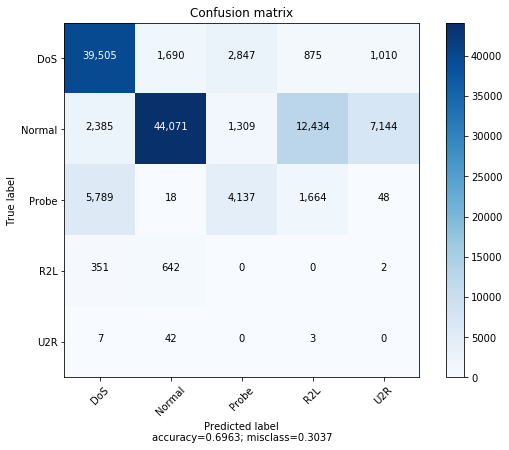

In [145]:
metrics_df_5(y_train, y_pred)

In [147]:
metrics_attack(y_train, y_pred)


Accuracy: 0.69628
Normalized MI : 	 0.42687412188589413
Adj_Rand_score : 	 0.4597298181807143
HomogenityScore : 	 0.504258703043529

Micro Precision: 0.69628
Micro Recall: 0.69628
Micro F1-score: 0.69628

Macro Precision: 0.45395
Macro Recall: 0.37390
Macro F1-score: 0.40602

Weighted Precision: 0.85304
Weighted Recall: 0.69628
Weighted F1-score: 0.75896


## Predicting on test data

In [148]:
kdd_test.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15
0,0.381360,0.530387,0.660045,0.724622,0.109395,-0.035172,-0.744237,-0.495375,-0.497708,0.305404,-0.689667,0.426100,0.053013,-0.169633,-0.416770,0.179120
1,0.343970,0.552332,0.640551,0.708869,0.098376,0.062561,-0.747867,-0.485042,-0.502715,0.320202,-0.672085,0.405334,0.043815,-0.094157,-0.397532,0.144064
2,0.524688,0.586094,-0.459716,0.012303,0.448023,-0.054178,-0.491327,-0.444742,-0.147500,-0.564727,-0.481381,-0.394228,-0.134288,0.237548,0.365072,-0.395849
3,0.358706,-0.362773,0.384644,-0.502299,0.377956,0.562362,-0.283287,0.580169,-0.692474,-0.566699,0.612007,-0.860818,0.183996,0.469404,0.539052,0.739437
4,-0.139059,-0.037270,0.346193,0.219383,-0.352120,0.490178,-0.012989,0.209455,-0.671113,-0.639188,-0.400703,0.584562,0.178015,-0.370203,0.030700,-0.580754


In [149]:
kmeans_2.fit(kdd_test)
test_pred_2=kmeans_2.predict(kdd_test)

In [150]:
kmeans_5.fit(kdd_test)
test_pred_5=kmeans_5.predict(kdd_test)

In [151]:
y_test=kdd_test_label['label_5']
kdd_test_label['pred_5']=test_pred_5

In [152]:
print(pd.crosstab(y_test, test_pred_5),"\n")


col_0       0    1     2     3     4
label_5                             
DoS        14  706  4596  1091   760
Normal   1776   93    84  6650  1108
Probe     317  241  1334     1   528
R2L       514    4   116     1  2250
U2R         0    0     0     0    67
unknown     0    0     0     0   293 



In [153]:
y_test=kdd_test_label['Class_2']
kdd_test_label['pred_2']=test_pred_2

In [154]:
print(pd.crosstab(y_test, test_pred_2),"\n")


col_0       0      1
Class_2             
0        1093  11740
1        6652   3059 



In [155]:
print(pd.crosstab(kdd_test_label['Class_5'], test_pred_2),"\n")


col_0       0     1
Class_5            
0        1091  6076
1        6652  3059
2           1  2420
3           1  2884
4           0    67
5           0   293 



In [156]:
kdd_test_label['pred_2']=kdd_test_label['pred_2'].apply(lambda x:1 if x==0 else 0)

In [157]:
y_pred=kdd_test_label['pred_2']

In [158]:
print(pd.crosstab(kdd_test_label['label_5'], y_pred),"\n")


pred_2      0     1
label_5            
DoS      6076  1091
Normal   3059  6652
Probe    2420     1
R2L      2884     1
U2R        67     0
unknown   293     0 



In [159]:
print(pd.crosstab(y_test, y_pred),"\n")


pred_2       0     1
Class_2             
0        11740  1093
1         3059  6652 




*********************************SKLEARN METRICS***********

             precision    recall  f1-score   support

          0       0.79      0.91      0.85     12833
          1       0.86      0.68      0.76      9711

avg / total       0.82      0.82      0.81     22544
 


Confusion Matrix :
 [[11740  1093]
 [ 3059  6652]]
Accuracy : 	 0.8158268275372604
F1_score : 	 0.7621448212648946
Precision : 	 0.8588766946417044
Recall : 	 0.6849963958397693
ROC_AUC : 	 0.7999126762180223

*************************CLUSTER PAARMETERS***********

Normalized MI : 	 0.315476769724408
Adj_Rand_score : 	 0.39783204951494927
HomogenityScore : 	 0.3060675547140964

*************************CONFUSION MATRIX***********

[[11740  1093]
 [ 3059  6652]]
Sensitivity :	 0.6849963958397693
Specificity :	 0.9148289565962753
Precision :	 0.8588766946417044
Accuracy :	 0.8158268275372604
Detection Rate  :	 0.29506742370475514
False Positive Rate :	 0.08517104340372478
False Negative Rate  :	 0.315003604160230

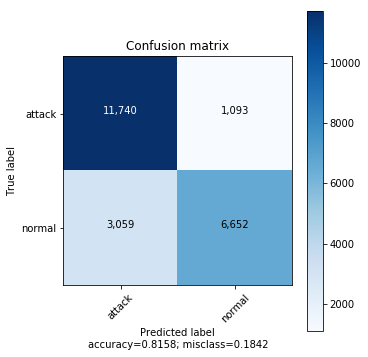

In [160]:
metrics_df_2(y_test, y_pred)

In [167]:
kdd_train.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15
0,-0.610296,0.015692,0.244279,0.352686,0.098302,0.051205,0.565617,-0.170328,-0.480297,0.511893,-0.345205,-0.250245,0.153788,0.130683,-0.366020,-0.346798
1,-0.320414,0.225041,0.196417,-0.384774,0.432062,0.406118,0.382800,0.559388,-0.519861,-0.177007,-0.744207,-0.138819,-0.454534,0.392854,0.114113,0.263254
2,-0.210321,-0.071026,-0.171084,-0.365576,-0.110038,-0.556859,-0.402690,0.084724,-0.611879,0.180990,0.096818,-0.182272,0.125824,-0.161088,0.018052,-0.070688
3,-0.441472,0.564467,0.409877,0.100399,0.048755,-0.295239,0.259262,0.316888,0.427560,0.090938,0.158638,0.115800,0.299641,0.295628,-0.219366,-0.127190
4,-0.478021,0.467678,0.487974,0.169323,0.023412,-0.274956,0.272012,0.305003,0.447077,-0.031349,0.182353,0.156466,0.240548,0.295724,-0.003925,-0.067835


In [168]:
kdd_label.columns

Index(['attack', 'label_2', 'label_5', 'Class_2', 'Class_5', 'pred_2',
       'pred_5', 'pred_lb'],
      dtype='object')

In [169]:
df=pd.concat([kdd_train,kdd_label],axis=1)

In [170]:
df.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_14,feature_15,attack,label_2,label_5,Class_2,Class_5,pred_2,pred_5,pred_lb
0,-0.610296,0.015692,0.244279,0.352686,0.098302,0.051205,0.565617,-0.170328,-0.480297,0.511893,...,-0.366020,-0.346798,normal,normal,Normal,1,1,1,4,Normal
1,-0.320414,0.225041,0.196417,-0.384774,0.432062,0.406118,0.382800,0.559388,-0.519861,-0.177007,...,0.114113,0.263254,normal,normal,Normal,1,1,1,1,R2L
2,-0.210321,-0.071026,-0.171084,-0.365576,-0.110038,-0.556859,-0.402690,0.084724,-0.611879,0.180990,...,0.018052,-0.070688,neptune,attack,DoS,0,0,0,3,DoS
3,-0.441472,0.564467,0.409877,0.100399,0.048755,-0.295239,0.259262,0.316888,0.427560,0.090938,...,-0.219366,-0.127190,normal,normal,Normal,1,1,1,4,Normal
4,-0.478021,0.467678,0.487974,0.169323,0.023412,-0.274956,0.272012,0.305003,0.447077,-0.031349,...,-0.003925,-0.067835,normal,normal,Normal,1,1,1,4,Normal


In [171]:
out_file=inp_file_train.split(".")[0] + "_KM.csv"
print(out_file)

kdd_train_prep2_AE_16_KM.csv


In [172]:
df.to_csv(out_file,index=False)